[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pulseq/ISMRM-Virtual-Meeting--February-24-26-2026/blob/main/tutorials/day2_PyPulseq/day2_PyPulseq_02_MRpro_recon.ipynb)

# PyPulseq Example Notebook: Image reconstruction using [MRpro](https://github.com/PTB-MR/mrpro)

In [1]:
%pip install mrpro[notebooks]

Note: you may need to restart the kernel to use updated packages.


## Reconstruction of radial 2D scanner data

In this example, we will
- download the raw data (MRD format) of a 2D radial scan and the Pulseq sequence that was used for the acquisition
- calculate the trajectory from the Pulseq sequence
- reconstruct the image using MRpro's DirectReconstruction class

In [2]:
# Download raw data from Zenodo
import tempfile
from pathlib import Path

import mrpro
import numpy as np
import torch
import zenodo_get

tmp = tempfile.TemporaryDirectory()  # RAII, automatically cleaned up
data_folder = Path(tmp.name)

zenodo_get.download(record='14617082', retry_attempts=5, output_dir=data_folder)

2026-02-25 10:59:46.838 | INFO     | zenodo_get.zget:_zenodo_download_logic:306 - Output directory: C:\Users\Patrick\AppData\Local\Temp\tmpv74lltl_
2026-02-25 10:59:47.133 | INFO     | zenodo_get.zget:_zenodo_download_logic:404 - Title: 2D Radial MR raw data and Pulseq sequences
2026-02-25 10:59:47.134 | INFO     | zenodo_get.zget:_zenodo_download_logic:416 - Total size: 18.7 MB
2026-02-25 10:59:47.135 | INFO     | zenodo_get.zget:_zenodo_download_logic:417 - Number of files: 6
2026-02-25 10:59:56.760 | SUCCESS  | zenodo_get.zget:_zenodo_download_logic:461 - All specified files have been processed.


### Using KTrajectoryPulseq - Trajectory from pulseq sequence file
This will calculate the trajectory from the pulseq sequence file
using the PyPulseq trajectory calculator. This method
requires the pulseq sequence file that was used to acquire the data.
The path to the sequence file is provided as an argument to KTrajectoryPulseq.

In [3]:
import matplotlib.pyplot as plt

# Define path to Pulseq sequence and ISMRMRD data
seq_path = data_folder / 'radial2D_96spokes_golden_angle.seq'
mrd_path = data_folder / 'radial2D_96spokes_golden_angle_with_traj.h5'

# Create PyPulseq trajectory calculator
traj = mrpro.data.traj_calculators.KTrajectoryPulseq(seq_path)

# Read MRD raw data into KData objec
kdata = mrpro.data.KData.from_file(mrd_path, traj)



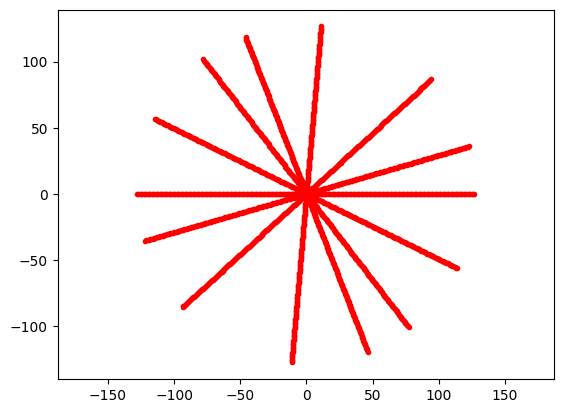

In [4]:
# Plot the k-space trajectory (first 7 spokes)
def get_slice(arr):
    return arr[0, 0, 0, :7, :].squeeze()

plt.plot(get_slice(kdata.traj.kx), get_slice(kdata.traj.ky), ".", color="red")
plt.axis('equal')
plt.show()

In [5]:
# Reconstruct the image
reconstruction = mrpro.algorithms.reconstruction.DirectReconstruction(kdata)
idata = reconstruction(kdata)
image = idata.rss()

c:\Users\Patrick\miniforge3\envs\pypulseq_demo\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


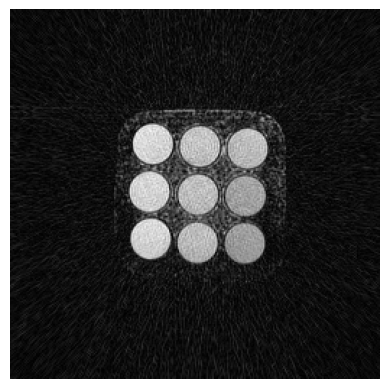

In [6]:
# Plot the image
plt.imshow(image.squeeze(), cmap='grey')
plt.axis('off')
plt.show()

## Reconstruction of multi-echo spiral TSE 2D scanner data

In [7]:
zenodo_get.download(record='18749100', retry_attempts=5, output_dir=data_folder)

# Define path to Pulseq sequence and ISMRMRD data
seq_path2 = data_folder / 'spiral_tse_tr_4000_te_16_nechos_10_nspirals_160.seq'
mrd_path2 = data_folder / 'spiral_tse_tr_4000_te_16_nechos_10_nspirals_160.mrd'

# Create KTrajectory object
traj2 = mrpro.data.traj_calculators.KTrajectoryPulseq(seq_path2)

# Read MRD raw data into KData objec
kdata2 = mrpro.data.KData.from_file(mrd_path2, traj2)
kdata2.header.recon_matrix.x = kdata2.header.recon_matrix.y



2026-02-25 11:00:04.195 | INFO     | zenodo_get.zget:_zenodo_download_logic:306 - Output directory: C:\Users\Patrick\AppData\Local\Temp\tmpv74lltl_
2026-02-25 11:00:04.491 | INFO     | zenodo_get.zget:_zenodo_download_logic:404 - Title: 2D Multi-echo TSE spiral MR raw data and Pulseq sequences
2026-02-25 11:00:04.492 | INFO     | zenodo_get.zget:_zenodo_download_logic:416 - Total size: 76.4 MB
2026-02-25 11:00:04.492 | INFO     | zenodo_get.zget:_zenodo_download_logic:417 - Number of files: 4
2026-02-25 11:00:20.926 | SUCCESS  | zenodo_get.zget:_zenodo_download_logic:461 - All specified files have been processed.


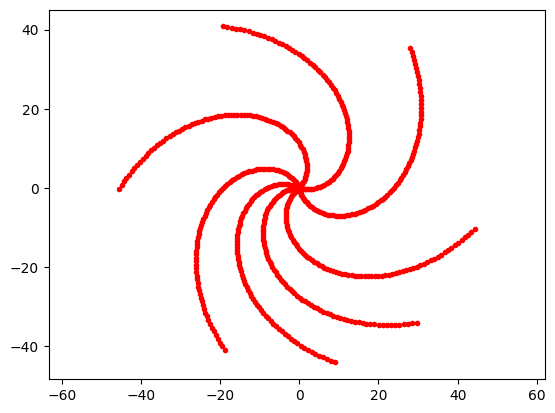

In [8]:
# Plot the k-space trajectory (first 7 interleaves)
plt.plot(get_slice(kdata2.traj.kx), get_slice(kdata2.traj.ky), ".", color="red", )
plt.axis('equal')
plt.show()

In [9]:
# Reconstruct the images
reconstruction2 = mrpro.algorithms.reconstruction.DirectReconstruction(kdata2)
idata2 = reconstruction2(kdata2)
image2 = idata2.rss()

c:\Users\Patrick\miniforge3\envs\pypulseq_demo\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


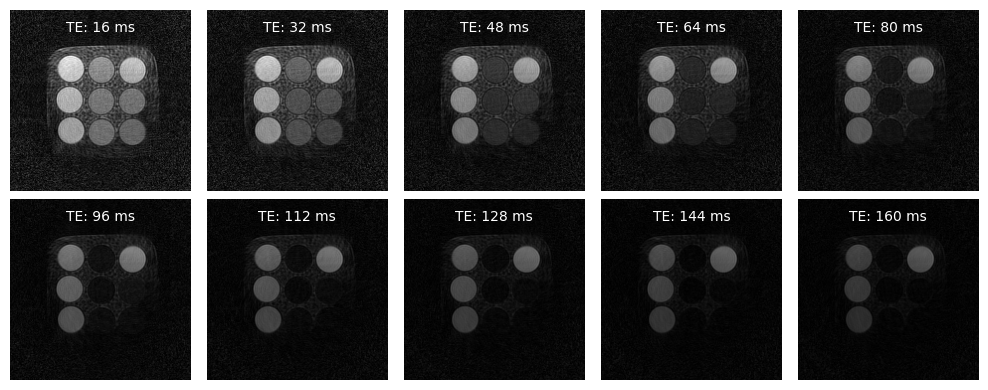

In [10]:
# Plot the images
te = np.arange(1, 11, 1, dtype=np.float32) * 16e-3
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
vmax = image2.max().item()


for i, ax in enumerate(axes.flatten()):
    ax.imshow(image2[i].squeeze(), cmap='grey', vmin=0, vmax=vmax)
    ax.axis('off')
    ax.text(0.5, 0.9, f'TE: {te[i] * 1000:.0f} ms', transform=ax.transAxes,
            ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

## Estimate quantitative T2 parameter map

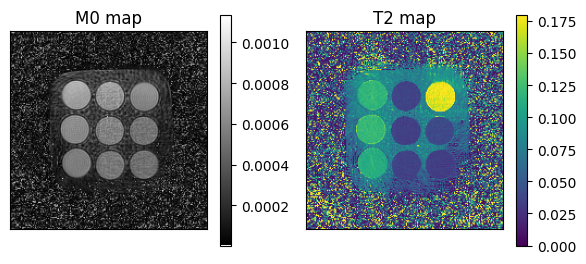

In [11]:

import numpy as np
from mrpro.operators import DictionaryMatchOp
from mrpro.operators.models import MonoExponentialDecay

model = MonoExponentialDecay(decay_time=te)
dictionary = DictionaryMatchOp(model, index_of_scaling_parameter=0)
dictionary.append(torch.tensor(1.0), torch.linspace(0.01, 0.8, 1000)[None, :])
m0_match, t2_match = dictionary(np.squeeze(idata2.data[:, 0, 0]))
t2_measured = t2_match.numpy().squeeze()
m0_measured = m0_match.numpy().squeeze()

fig, ax = plt.subplots(1, 2, figsize=(7, 3))
for cax in ax:
    cax.set_xticks([])
    cax.set_yticks([])


im = ax[0].imshow(np.abs(m0_measured), cmap='grey')
ax[0].set_title('M0 map')
fig.colorbar(im, ax=ax[0])


im = ax[1].imshow(np.abs(t2_measured), clim=(0,0.18), cmap='viridis')
ax[1].set_title('T2 map')
fig.colorbar(im, ax=ax[1])



## Additional MRpro examples

More examples can be found on the [MRpro GitHub page](https://github.com/PTB-MR/MRpro) in the [MRpro Examples](https://github.com/PTB-MR/mrpro/tree/main/examples/notebooks) directory or [MRpro Documentation](https://docs.mrpro.rocks/).
